# Part 4 — The ARIMA Family

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

Part 3 forecast by **smoothing components** — level, trend, season. Part 4 takes
the other great classical route: model a series' **autocorrelation structure
directly**. This is the world of **AR**, **MA**, **ARIMA**, and **SARIMA** — the
Box–Jenkins methodology — and it is where the stationarity tests and ACF/PACF
reading from **Part 2** finally pay off, because they are precisely the tools we
use to choose model orders.

### What you will learn
1. The intuition and math of **AR**, **MA**, and **ARMA** processes
2. How **ACF/PACF signatures** identify model orders (Box–Jenkins)
3. **ARIMA(p,d,q)** — where the "I" (differencing) comes from, and how *d* is chosen
4. **Order selection** by ACF/PACF vs. information criteria (**AIC/BIC**), and **`auto_arima`**
5. **Seasonal ARIMA (SARIMA)** and **SARIMAX** with exogenous regressors
6. **Residual diagnostics** — Ljung–Box, normality, heteroscedasticity
7. A head-to-head **benchmark vs. Part 3's ETS winner** and the baselines

### Dataset & continuity
Still `monthly_price.csv` (356 months, 1992–2021). We forecast the **Food Price
Index** on the same **24-month hold-out** as Part 3, so the numbers are directly
comparable. Part 3's automatically selected model was **ETS(M,Ad,N)**, and — a
sobering result — the **Drift baseline** actually won that hold-out because the
test window is the 2020–21 price surge. ARIMA now gets its turn.

## 0. Setup, data, split, and shared helpers

We reuse the exact loading, split, metrics, and baselines from Part 3.

In [1]:
import warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

warnings.simplefilter("ignore", ConvergenceWarning)
warnings.simplefilter("ignore", ValueWarning)
warnings.simplefilter("ignore", UserWarning)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "date"
df = df.asfreq("MS")

H = 24
y = df["Food_Price_Index"]
train, test = y.iloc[:-H], y.iloc[-H:]

def mae(a, p):  return np.mean(np.abs(a - p))
def rmse(a, p): return np.sqrt(np.mean((a - p) ** 2))
def mape(a, p): return np.mean(np.abs((a - p) / a)) * 100
def score(name, a, p):
    return {"model": name, "MAE": round(mae(a, p), 3),
            "RMSE": round(rmse(a, p), 3), "MAPE%": round(mape(a, p), 2)}

# baselines carried over from Part 3
naive = pd.Series(train.iloc[-1], index=test.index)
drift = pd.Series(train.iloc[-1] + (train.iloc[-1]-train.iloc[0])/(len(train)-1)
                  * np.arange(1, H+1), index=test.index)
snaive = pd.Series(np.tile(train.iloc[-12:].values, 2)[:H], index=test.index)
print("train:", len(train), "| test:", len(test))

train: 332 | test: 24


## 1. The idea: model the autocorrelation, not the components

Where exponential smoothing describes a series by its *level, trend, and season*,
an ARIMA model describes it by **how each value relates to its own past values and
past shocks**. The name unpacks into three ideas:

- **AR** — *AutoRegressive*: today is a regression on **recent past values**.
- **I** — *Integrated*: we model the **differenced** series, because ARMA requires
  **stationarity** (Part 2). The number of differences is **d**.
- **MA** — *Moving Average*: today also depends on **recent past forecast errors**
  (shocks). (This is a different "MA" from the moving-average *smoother* of Part 3.)

An **ARIMA(p, d, q)** model applies an ARMA(p, q) to a series differenced **d**
times. The whole workflow is: *difference until stationary → read p and q from the
correlograms → fit → check residuals*.

## 2. AR, MA, ARMA — intuition through simulation

The cleanest way to build intuition is to **simulate** processes with *known*
orders and look at their fingerprints. `statsmodels`' `ArmaProcess` does this.
(Note its lag-polynomial sign convention: an AR coefficient φ is entered as
`[1, -φ]`.)

### AR(1): today regresses on yesterday

$$y_t = \phi\, y_{t-1} + \varepsilon_t$$

φ controls persistence: φ near +1 gives slow, trending drift; a negative φ gives
rapid oscillation. The **ACF of an AR(1) decays geometrically**, while its **PACF
cuts off sharply after lag 1** — because once you account for lag 1, no direct
relationship remains at deeper lags.

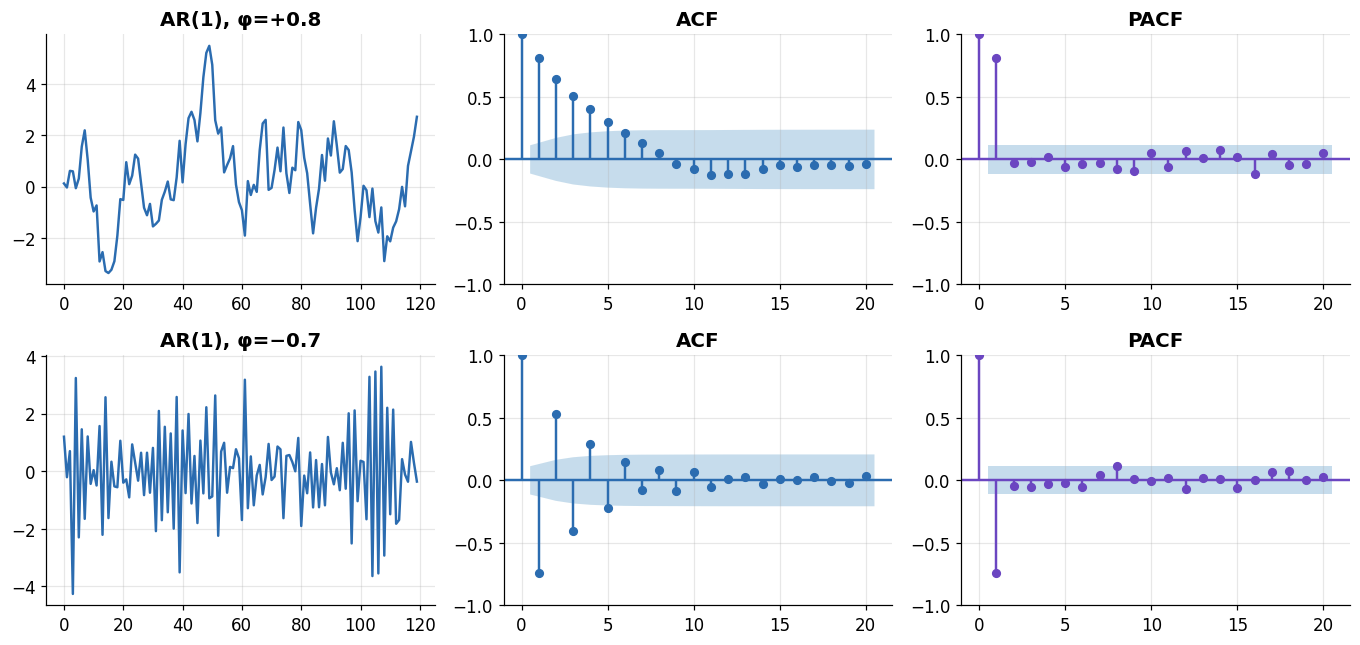

In [2]:
rng = np.random.default_rng(0)
ar_pos = ArmaProcess([1, -0.8], [1]).generate_sample(300, distrvs=rng.standard_normal)
ar_neg = ArmaProcess([1,  0.7], [1]).generate_sample(300, distrvs=rng.standard_normal)

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6))
for row, (data, label) in enumerate([(ar_pos, "AR(1), φ=+0.8"),
                                      (ar_neg, "AR(1), φ=−0.7")]):
    axes[row,0].plot(data[:120], color=PALETTE[0]); axes[row,0].set_title(label)
    plot_acf(data, lags=20, ax=axes[row,1], color=PALETTE[0],
             vlines_kwargs={"colors": PALETTE[0]}); axes[row,1].set_title("ACF")
    plot_pacf(data, lags=20, ax=axes[row,2], method="ywm", color=PALETTE[3],
              vlines_kwargs={"colors": PALETTE[3]}); axes[row,2].set_title("PACF")
plt.tight_layout(); plt.show()

Read the top row (φ=+0.8): the series drifts, the **ACF tails off** slowly, and
the **PACF has a single spike at lag 1**. The bottom row (φ=−0.7) oscillates and
its ACF alternates sign — but the PACF still cuts off after lag 1. **PACF cutoff ⇒
AR order.**

### MA(1): today depends on yesterday's shock

$$y_t = \varepsilon_t + \theta\, \varepsilon_{t-1}$$

An MA(q) process is the **mirror image** of AR: its **ACF cuts off after lag q**
while its **PACF tails off**.

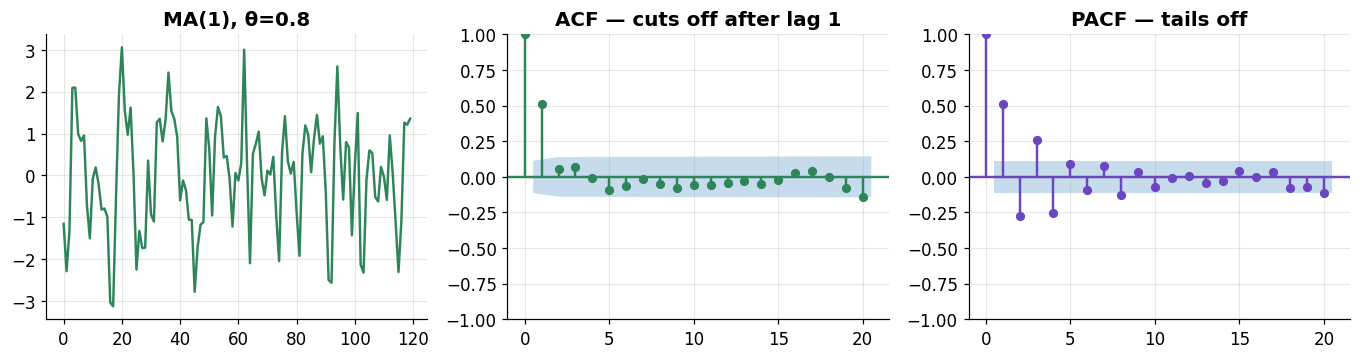

In [3]:
ma1 = ArmaProcess([1], [1, 0.8]).generate_sample(300, distrvs=rng.standard_normal)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
axes[0].plot(ma1[:120], color=PALETTE[2]); axes[0].set_title("MA(1), θ=0.8")
plot_acf(ma1, lags=20, ax=axes[1], color=PALETTE[2], vlines_kwargs={"colors": PALETTE[2]})
axes[1].set_title("ACF — cuts off after lag 1")
plot_pacf(ma1, lags=20, ax=axes[2], method="ywm", color=PALETTE[3], vlines_kwargs={"colors": PALETTE[3]})
axes[2].set_title("PACF — tails off")
plt.tight_layout(); plt.show()

This mirror symmetry is the heart of **Box–Jenkins identification**:

| Process | ACF | PACF |
|---|---|---|
| **AR(p)** | tails off | **cuts off after lag p** |
| **MA(q)** | **cuts off after lag q** | tails off |
| **ARMA(p,q)** | tails off | tails off |

When *both* tail off, you have a mixed ARMA and lean on information criteria to
pin down the orders.

## 3. Choosing *d*, then reading *p* and *q* from our data

**Step 1 — the differencing order *d*.** We difference until the series is
stationary, using the ADF test from Part 2. The Food Price Index needs exactly one
difference.

In [4]:
from statsmodels.tsa.stattools import adfuller
p_raw  = adfuller(train.dropna(), autolag="AIC", result_object=False)[1]
p_diff = adfuller(train.diff().dropna(), autolag="AIC", result_object=False)[1]
print(f"ADF p-value, raw       : {p_raw:.3f}  -> {'stationary' if p_raw<.05 else 'NON-stationary'}")
print(f"ADF p-value, 1st diff  : {p_diff:.3f}  -> {'stationary' if p_diff<.05 else 'NON-stationary'}")
print("=> choose d = 1")

ADF p-value, raw       : 0.379  -> NON-stationary
ADF p-value, 1st diff  : 0.000  -> stationary
=> choose d = 1


**Step 2 — read *p* and *q*** from the ACF/PACF of the **differenced** series.

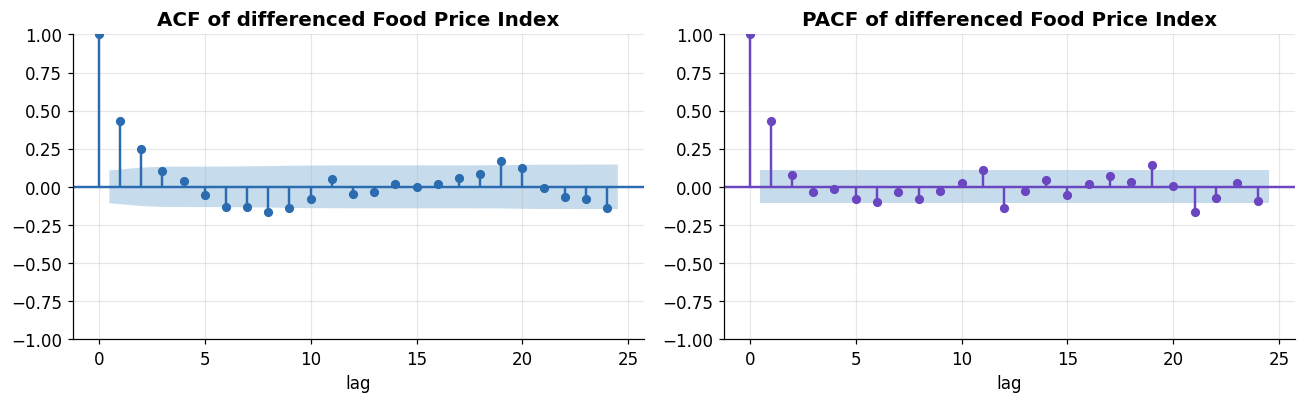

In [5]:
d1 = train.diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
plot_acf(d1, lags=24, ax=axes[0], color=PALETTE[0], vlines_kwargs={"colors": PALETTE[0]})
axes[0].set_title("ACF of differenced Food Price Index")
plot_pacf(d1, lags=24, ax=axes[1], method="ywm", color=PALETTE[3], vlines_kwargs={"colors": PALETTE[3]})
axes[1].set_title("PACF of differenced Food Price Index")
for a in axes: a.set_xlabel("lag")
plt.tight_layout(); plt.show()

The **PACF cuts off sharply after lag 1** (only lag 1 clears the band) while the
**ACF tails off** over a few lags — the classic **AR(1)** signature. Applied to
the once-differenced series, that reads as a tentative **ARIMA(1, 1, 0)**. This is
our ACF/PACF-identified candidate; next we let information criteria second-guess
it.

## 4. Fitting an ARIMA model

We fit the identified **ARIMA(1,1,0)** with `statsmodels` and read the summary —
coefficients, and the **AIC/BIC** we'll use for selection.

In [6]:
m110 = ARIMA(train, order=(1, 1, 0)).fit()
print(m110.summary().tables[0])
print(m110.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:       Food_Price_Index   No. Observations:                  332
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -755.533
Date:                Fri, 11 Sep 2026   AIC                           1515.067
Time:                        01:10:21   BIC                           1522.671
Sample:                    01-01-1992   HQIC                          1518.100
                         - 08-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4329      0.035     12.511      0.000       0.365       0.501
sigma2         5.6219      0.224     25.116      0.000       5.183       6.061


The lone AR(1) coefficient is positive and highly significant, consistent with
the momentum we saw. `AIC`/`BIC` appear at the top — lower is better. Let's produce
a forecast with a prediction interval; the ARIMA state-space form gives these
analytically via `get_forecast`.

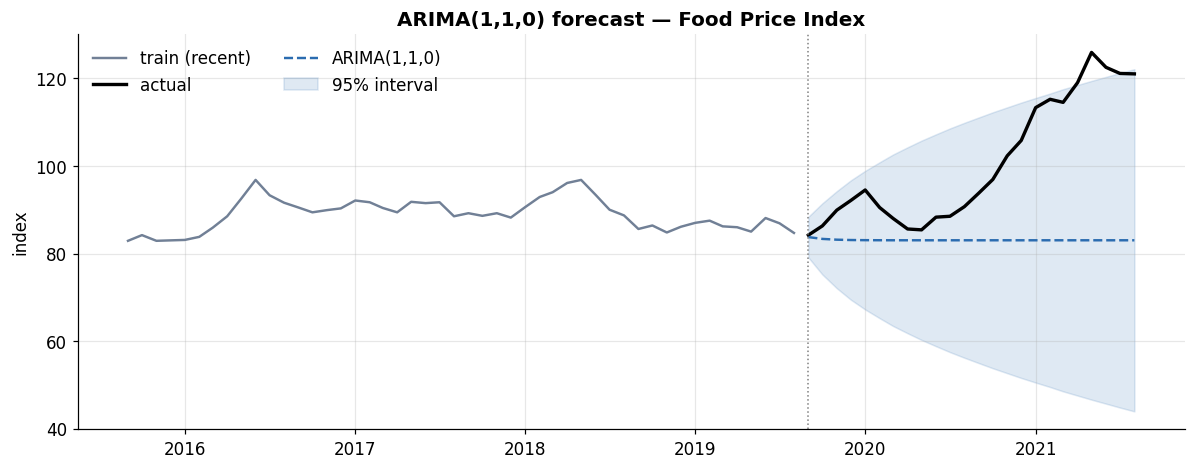

{'model': 'ARIMA(1,1,0)', 'MAE': np.float64(17.563), 'RMSE': np.float64(22.55), 'MAPE%': np.float64(15.89)}


In [7]:
fc = m110.get_forecast(H)
sf = fc.summary_frame(alpha=0.05)   # mean, mean_ci_lower, mean_ci_upper

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(train.index[-48:], train.iloc[-48:], color=PALETTE[5], label="train (recent)")
ax.plot(test.index, test, color="black", lw=2.2, label="actual")
ax.plot(sf.index, sf["mean"], color=PALETTE[0], ls="--", label="ARIMA(1,1,0)")
ax.fill_between(sf.index, sf["mean_ci_lower"], sf["mean_ci_upper"],
                color=PALETTE[0], alpha=0.15, label="95% interval")
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title("ARIMA(1,1,0) forecast — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()
print(score("ARIMA(1,1,0)", test, sf["mean"]))

Like the ETS forecast in Part 3, the point forecast is nearly flat (a differenced
AR(1) has short memory and reverts to a drift), so it too **misses the 2020–21
surge** — but the interval widens to keep the actual within reach. The interesting
question is whether a *richer* ARIMA does better.

## 5. Order selection by information criteria

The ACF/PACF gives a principled *starting* order; **information criteria** refine
it. **AIC** and **BIC** both trade goodness-of-fit against the number of
parameters; **BIC** penalizes complexity more heavily, so it tends to pick smaller
models. We grid-search over $(p, q)$ with $d=1$ fixed and rank by AIC.

In [8]:
rows = []
for p, q in itertools.product(range(4), range(4)):
    try:
        r = ARIMA(train, order=(p, 1, q)).fit()
        rows.append({"order": f"({p},1,{q})", "p": p, "q": q,
                     "AIC": round(r.aic, 2), "BIC": round(r.bic, 2)})
    except Exception:
        pass
grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
grid.head(8)

,order,p,q,AIC,BIC
0,"(3,1,2)",3,2,1513.73,1536.54
1,"(2,1,2)",2,2,1513.96,1532.97
2,"(3,1,3)",3,3,1514.75,1541.37
3,"(1,1,0)",1,0,1515.07,1522.67
4,"(2,1,0)",2,0,1515.19,1526.59
5,"(2,1,3)",2,3,1515.35,1538.16
6,"(1,1,1)",1,1,1515.52,1526.92
7,"(3,1,0)",3,0,1516.69,1531.90


In [9]:
best_aic_order = tuple(int(x) for x in
                       grid.iloc[0]["order"].strip("()").split(","))
best_bic_row = grid.sort_values("BIC").iloc[0]
print("Lowest AIC :", grid.iloc[0]["order"], "AIC =", grid.iloc[0]["AIC"])
print("Lowest BIC :", best_bic_row["order"], "BIC =", best_bic_row["BIC"])
print("\nNote: our ACF/PACF pick, (1,1,0), sits at AIC =",
      float(grid.loc[grid.order=='(1,1,0)','AIC'].iloc[0]))

Lowest AIC : (3,1,2) AIC = 1513.73
Lowest BIC : (1,1,0) BIC = 1522.67

Note: our ACF/PACF pick, (1,1,0), sits at AIC = 1515.07


AIC prefers a **richer mixed model** than the eye suggested, while **BIC picks
exactly our parsimonious ACF/PACF candidate, (1,1,0)** — its heavier complexity
penalty rewards the simpler model. That disagreement is the norm, not a bug:
ACF/PACF gives a *parsimonious hypothesis*, AIC fine-tunes for in-sample fit, BIC
guards against over-parameterization. Which one actually *forecasts* better is an
empirical question we settle on the hold-out in Section 10 — so we carry **both**
the AIC winner and the simpler ACF/PACF/BIC pick into that benchmark.

In [10]:
m_aic = ARIMA(train, order=best_aic_order).fit()
aic_fc = m_aic.get_forecast(H).summary_frame(alpha=0.05)
print(score(f"ARIMA{best_aic_order}", test, aic_fc["mean"]))

{'model': 'ARIMA(3, 1, 2)', 'MAE': np.float64(18.087), 'RMSE': np.float64(22.887), 'MAPE%': np.float64(16.44)}


## 6. Automated search with `auto_arima`

Grid-searching by hand is fine for one series; for many, the `pmdarima` package's
**`auto_arima`** automates it — stepwise-searching $(p,d,q)(P,D,Q)_m$, testing for
the differencing orders, and minimizing an information criterion. It is the
practical workhorse for order selection.

In [11]:
from pmdarima import auto_arima
auto = auto_arima(train, seasonal=False, stepwise=True,
                  information_criterion="aic",
                  suppress_warnings=True, error_action="ignore")
print("auto_arima selected:", auto.order, " AIC =", round(auto.aic(), 2))
auto_fc = pd.Series(auto.predict(n_periods=H), index=test.index)
print(score(f"auto_arima{auto.order}", test, auto_fc))

auto_arima selected: (3, 1, 2)  AIC = 1513.73
{'model': 'auto_arima(3, 1, 2)', 'MAE': np.float64(18.087), 'RMSE': np.float64(22.887), 'MAPE%': np.float64(16.44)}


Here `auto_arima` confirms our AIC grid winner exactly. In general its stepwise
search can diverge slightly from an exhaustive grid, so treat it as a strong
default rather than an oracle — always confirm the choice with the **residual
diagnostics** below.

## 7. Seasonal ARIMA (SARIMA)

**SARIMA(p,d,q)(P,D,Q)ₘ** adds a *seasonal* triple plus a seasonal difference at
period **m** — seasonal AR (**P**), seasonal differencing (**D**), and seasonal MA
(**Q**) that operate at lags m, 2m, … . For monthly data m = 12, so a seasonal AR
term links each month to the same month a year earlier.

Our commodities are only lightly seasonal (Parts 1–2), so we demonstrate SARIMA on
**Rice price** and compare a seasonal specification against its non-seasonal
counterpart.

In [12]:
rice = df["Rice_Price"]; r_train, r_test = rice.iloc[:-H], rice.iloc[-H:]

sarima = ARIMA(r_train, order=(1,1,1), seasonal_order=(1,0,1,12)).fit()
plain  = ARIMA(r_train, order=(1,1,1)).fit()
print("SARIMA(1,1,1)(1,0,1)12  AIC =", round(sarima.aic, 1))
print("ARIMA (1,1,1)           AIC =", round(plain.aic, 1))

s_fc = sarima.get_forecast(H).summary_frame(alpha=0.05)
p_fc = plain.get_forecast(H).summary_frame(alpha=0.05)
pd.DataFrame([score("Rice SARIMA(1,1,1)(1,0,1)12", r_test, s_fc["mean"]),
              score("Rice ARIMA(1,1,1)",           r_test, p_fc["mean"])])

SARIMA(1,1,1)(1,0,1)12  AIC = 3080.6
ARIMA (1,1,1)           AIC = 3077.9


,model,MAE,RMSE,MAPE%
0,"Rice SARIMA(1,1,1)(1,0,1)12",54.235,64.617,10.72
1,"Rice ARIMA(1,1,1)",52.591,62.859,10.39


The seasonal terms buy only a small change here — the honest consequence of weak
seasonality in this dataset. On strongly seasonal series (electricity demand,
tourism, retail) the seasonal triple is decisive, and the mechanics are exactly
the same.

## 8. SARIMAX — adding exogenous regressors

**SARIMAX** extends the model with **exogenous predictors** (the "X"): external
variables that help explain the target. Economic intuition says **energy prices
drive food prices** (fuel, fertilizer, transport), so we add `Energy_Price_Index`
as a regressor for the Food Price Index.

In [13]:
exog = df["Energy_Price_Index"]
sarimax = ARIMA(train, exog=exog.iloc[:-H], order=best_aic_order).fit()
print(f"ARIMA{best_aic_order}          AIC = {m_aic.aic:6.1f}   (no exog)")
print(f"SARIMAX{best_aic_order}+energy AIC = {sarimax.aic:6.1f}   (with energy)")
print("\nEnergy coefficient:")
print(sarimax.summary().tables[1])

ARIMA(3, 1, 2)          AIC = 1513.7   (no exog)
SARIMAX(3, 1, 2)+energy AIC = 1468.0   (with energy)

Energy coefficient:
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Energy_Price_Index     0.1910      0.020      9.654      0.000       0.152       0.230
ar.L1                  2.0713      0.190     10.873      0.000       1.698       2.445
ar.L2                 -1.4383      0.256     -5.627      0.000      -1.939      -0.937
ar.L3                  0.2859      0.091      3.148      0.002       0.108       0.464
ma.L1                 -1.7103      0.188     -9.076      0.000      -2.080      -1.341
ma.L2                  0.8116      0.168      4.831      0.000       0.482       1.141
sigma2                 4.7754      0.293     16.285      0.000       4.201       5.350


Adding energy **sharply lowers the in-sample AIC** and its coefficient is
strongly significant — energy genuinely carries information about food prices.

> **The exogenous-forecasting catch.** To *forecast* with SARIMAX you need the
> regressor's **future** values, which you usually don't have. Three honest
> options: (1) use a **scenario** for the exog, (2) **forecast the exog first**
> with its own model, or (3) accept a lag so past exog predicts future target.
> Below we take a deliberate shortcut — feeding the model the **actual** future
> energy values — purely to illustrate the mechanism. This is an *oracle* forecast
> and an **upper bound** on what exog can buy; it is not a fair comparison against
> the univariate models.

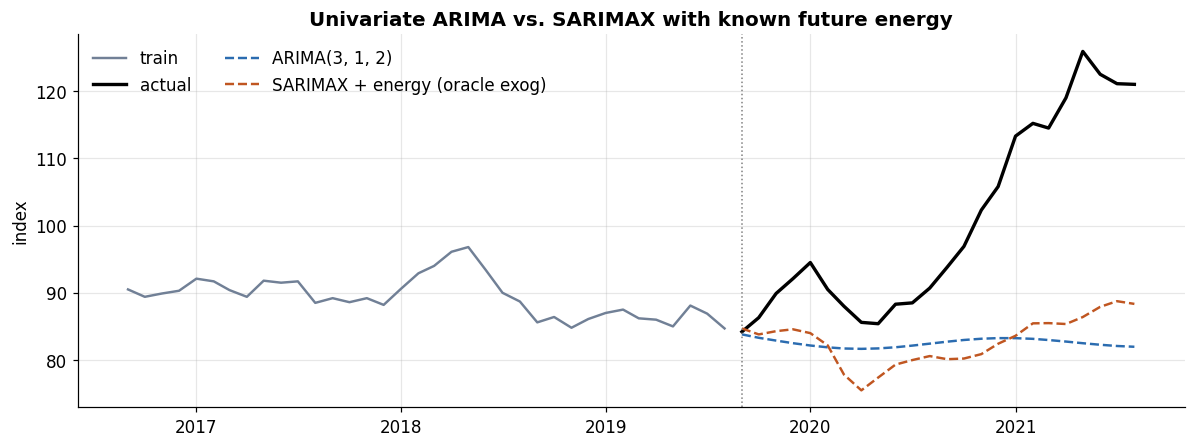

{'model': 'SARIMAX+energy (oracle)', 'MAE': np.float64(17.799), 'RMSE': np.float64(21.292), 'MAPE%': np.float64(16.49)}


In [14]:
oracle_fc = sarimax.get_forecast(H, exog=exog.iloc[-H:]).summary_frame(alpha=0.05)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(train.index[-36:], train.iloc[-36:], color=PALETTE[5], label="train")
ax.plot(test.index, test, color="black", lw=2.2, label="actual")
ax.plot(aic_fc.index, aic_fc["mean"], color=PALETTE[0], ls="--", label=f"ARIMA{best_aic_order}")
ax.plot(oracle_fc.index, oracle_fc["mean"], color=PALETTE[1], ls="--",
        label="SARIMAX + energy (oracle exog)")
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title("Univariate ARIMA vs. SARIMAX with known future energy")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()
print(score("SARIMAX+energy (oracle)", test, oracle_fc["mean"]))

With the actual energy path, SARIMAX improves on **every** univariate ARIMA/ETS
forecast here (RMSE ≈ 21.3 vs ≈ 22.5–23.8) — **the right covariate beats a
cleverer univariate model**. The gain is real but **modest**, and on this
shock-driven window it still doesn't overtake the drift baseline; the sharp
**in-sample AIC drop** is the clearer evidence that energy carries genuine
information. The honest caveat stands: in production you must supply or forecast
that covariate — exactly what the multivariate models of **Part 5** (VAR) are
built to do.

## 9. Residual diagnostics — did we capture the structure?

A fitted ARIMA is only trustworthy if its **residuals are white noise** — no
leftover autocorrelation, roughly constant variance, approximately normal. If
structure remains in the residuals, the model missed something. `statsmodels`
gives a four-panel diagnostic in one call.

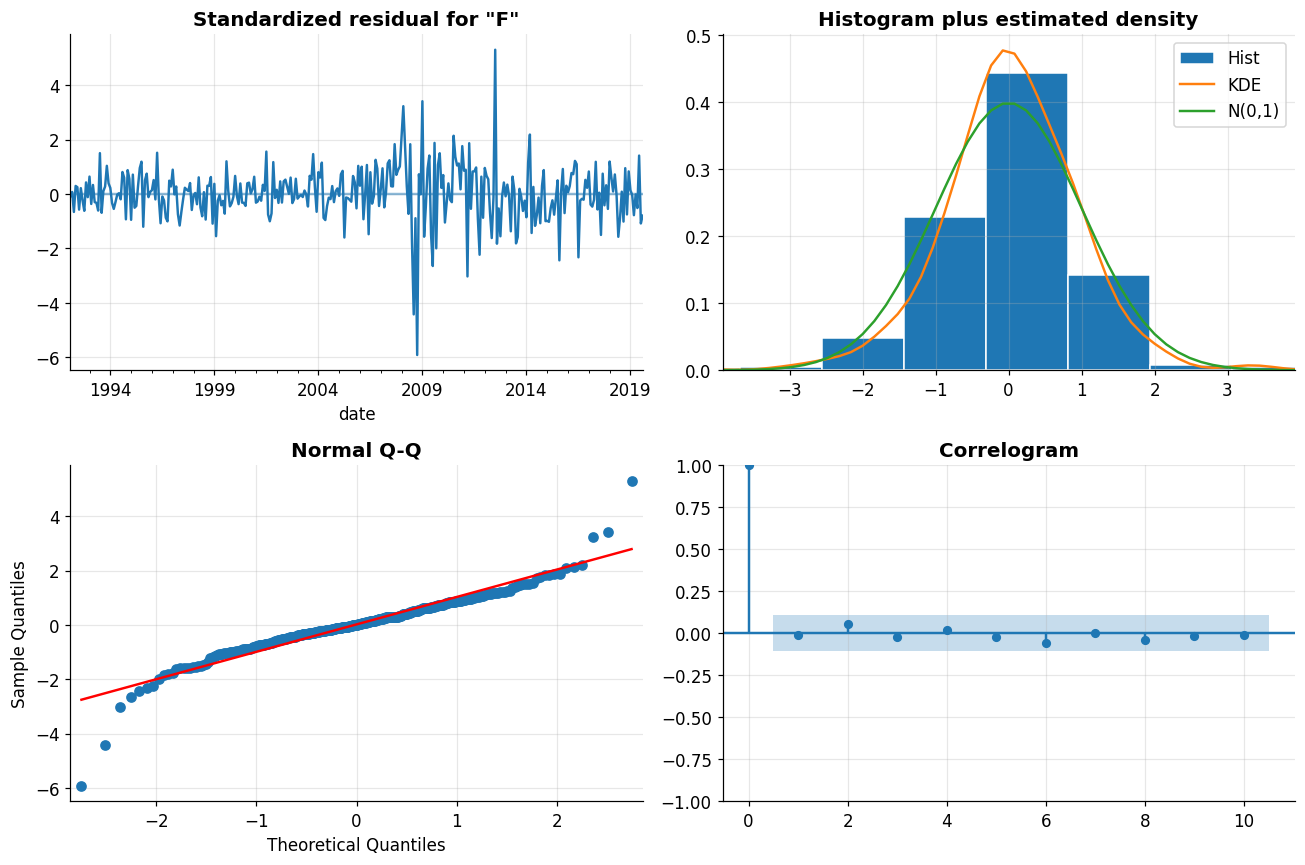

In [15]:
m_aic.plot_diagnostics(figsize=(12, 8))
plt.tight_layout(); plt.show()

Reading the four panels for our AIC model:

- **Standardized residuals (top-left)** — should look like noise around zero. Ours
  do broadly, but with **violent spikes at 2008 and 2020** — the shocks the model
  can't explain.
- **Histogram + KDE vs. N(0,1) (top-right)** — the residual density has **heavier
  tails** than the normal; extreme months are more common than a normal allows.
- **Normal Q–Q (bottom-left)** — points bend away from the line **at the tails**,
  confirming the heavy tails.
- **Correlogram (bottom-right)** — this is the key one: **no significant spikes**
  means the model has captured the autocorrelation.

The formal test for that last panel is **Ljung–Box** (H₀: residuals are
independent up to lag k; we *want* p > 0.05).

In [16]:
lb = acorr_ljungbox(m_aic.resid[1:], lags=[6, 12, 24], return_df=True)
lb = lb.round(4)
lb["verdict@0.05"] = np.where(lb["lb_pvalue"] > 0.05,
                              "white noise ✓", "structure left ✗")
lb

,lb_stat,lb_pvalue,verdict@0.05
6,2.8657,0.8255,white noise ✓
12,15.9510,0.1935,white noise ✓
24,29.2066,0.2125,white noise ✓


If Ljung–Box **fails to reject** at these lags, the residuals carry no remaining
autocorrelation — the model's mean structure is adequate. The non-normal, heavy-
tailed residuals are a *different* problem: they say the **variance** is not
constant (it explodes during crises). That is **conditional heteroscedasticity**,
and modelling it is exactly the job of **GARCH** in Part 5. A pragmatic partial fix
we already know is to model the **log** series, which tames the variance.

## 10. Benchmark — ARIMA vs. Part 3's ETS vs. baselines

Now the payoff: every serious model on the **same** 24-month hold-out.

> **Why we compare on hold-out error, not AIC.** An ARIMA with d=1 computes its
> likelihood on the *differenced* series, while ETS works on the *levels* — their
> AIC values are **not comparable**. Out-of-sample RMSE/MAE/MAPE, computed
> identically for every model, is the fair yardstick.

In [17]:
# refit Part 3's ETS winner on the same train
ets = ETSModel(train, error="mul", trend="add", damped_trend=True,
               initialization_method="estimated").fit(disp=False)
ets_fc = ets.forecast(H)

results = {
    "Naive":            naive,
    "Seasonal naive":   snaive,
    "Drift":            drift,
    "ETS(M,Ad,N)  [Part 3]": ets_fc,
    "ARIMA(1,1,0) [ACF/PACF]": sf["mean"],
    f"ARIMA{best_aic_order} [AIC grid]": aic_fc["mean"],
    f"auto_arima{auto.order}": auto_fc,
}
board = (pd.DataFrame([score(n, test, f) for n, f in results.items()])
           .sort_values("RMSE").reset_index(drop=True))
board

,model,MAE,RMSE,MAPE%
0,Drift,14.899,20.090,13.29
1,Seasonal naive,14.604,20.141,12.94
2,Naive,15.979,21.270,14.30
3,"ARIMA(1,1,0) [ACF/PACF]",17.563,22.550,15.89
4,"auto_arima(3, 1, 2)",18.087,22.887,16.44
5,"ARIMA(3, 1, 2) [AIC grid]",18.087,22.887,16.44
6,"ETS(M,Ad,N) [Part 3]",18.834,23.806,17.12


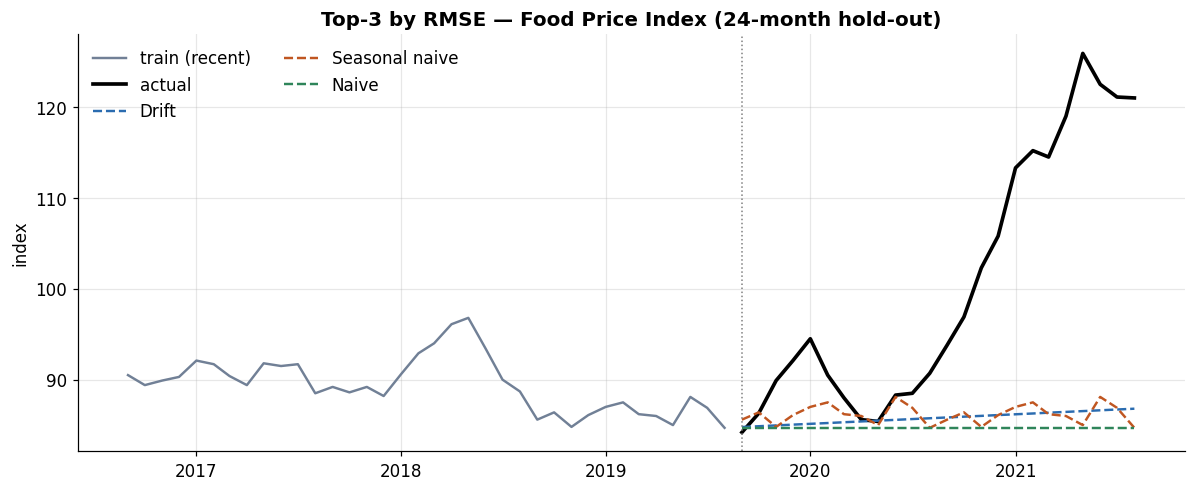

Best overall : Drift  (RMSE 20.09)
Best baseline RMSE: 20.09  ->  the baseline still wins


In [18]:
top3 = board["model"].head(3).tolist()
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(train.index[-36:], train.iloc[-36:], color=PALETTE[5], label="train (recent)")
ax.plot(test.index, test, color="black", lw=2.4, label="actual")
for name, c in zip(top3, PALETTE):
    ax.plot(results[name].index, results[name], color=c, ls="--", label=name)
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title(f"Top-3 by RMSE — Food Price Index ({H}-month hold-out)")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

win = board.iloc[0]
base = board[board.model.isin(["Naive","Seasonal naive","Drift"])]["RMSE"].min()
print(f"Best overall : {win['model']}  (RMSE {win['RMSE']})")
print(f"Best baseline RMSE: {base}  ->  "
      f"{'a model beats the baselines' if win['RMSE'] < base else 'the baseline still wins'}")

The honest story mirrors Part 3: on a hold-out dominated by an unforecastable
**shock**, ARIMA and ETS land in the **same neighbourhood** as each other and near
the **baselines** — because no univariate model can anticipate 2020–21 from the
prior data alone. Note too that the parsimonious **ARIMA(1,1,0)** actually edged
out the higher-order AIC pick out-of-sample: **lower in-sample AIC did not buy a
better forecast**, the very reason we validate on held-out data. That is not a
defeat; it is the correct diagnosis. The one thing that *did* move the needle was
**exogenous information** (energy in Section 8) — foreshadowing why we go
**multivariate** next.

## 11. Exercises

1. **Identify by eye.** Difference `Wheat_Price` once and read its ACF/PACF.
   Propose a tentative ARIMA order, fit it, and compare its AIC to a grid search.
2. **AIC vs BIC.** For `Maize_Price`, find the AIC-best and BIC-best orders. How
   far apart are they, and which forecasts the 24-month hold-out better?
3. **SARIMA where it matters.** Add a synthetic strong 12-month seasonal wave to a
   crop series, then show SARIMA decisively beats plain ARIMA on it.
4. **Forecast the exog honestly.** Redo Section 8 but forecast `Energy_Price_Index`
   with its own `auto_arima` first, then feed *that* into SARIMAX. How much of the
   oracle's advantage survives?
5. **Diagnostics.** Fit ARIMA to the **log** Food Price Index and compare the
   residual Q–Q plot and Ljung–Box to the raw-scale model. Did logging help the
   heavy tails?

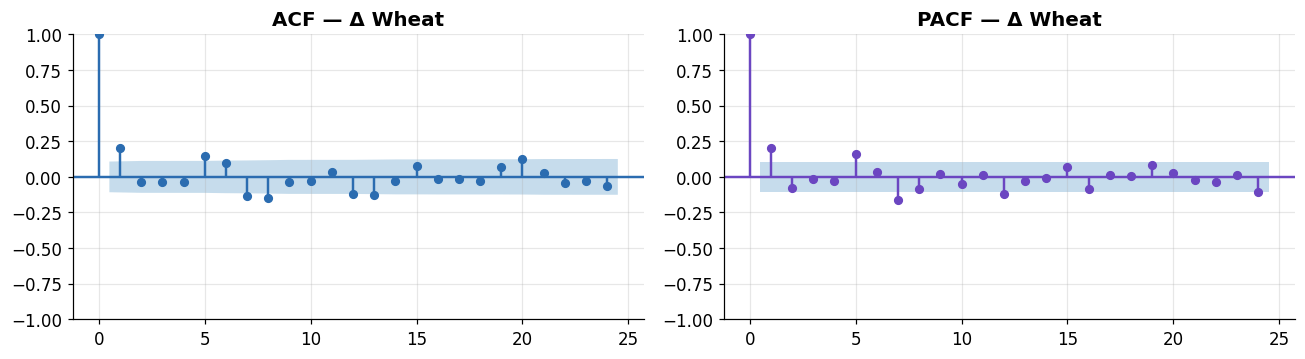

Wheat AIC-best: {'order': '(3,1,3)', 'AIC': 2672.6}


In [19]:
# --- Solution to Exercise 1 (setup) ---
w = df["Wheat_Price"]; w_tr = w.iloc[:-H]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
plot_acf(w_tr.diff().dropna(), lags=24, ax=axes[0], color=PALETTE[0], vlines_kwargs={"colors": PALETTE[0]})
plot_pacf(w_tr.diff().dropna(), lags=24, ax=axes[1], method="ywm", color=PALETTE[3], vlines_kwargs={"colors": PALETTE[3]})
axes[0].set_title("ACF — Δ Wheat"); axes[1].set_title("PACF — Δ Wheat")
plt.tight_layout(); plt.show()
wg = []
for p, q in itertools.product(range(4), range(4)):
    try:
        wg.append({"order": f"({p},1,{q})", "AIC": round(ARIMA(w_tr, order=(p,1,q)).fit().aic, 1)})
    except Exception: pass
print("Wheat AIC-best:", pd.DataFrame(wg).sort_values("AIC").iloc[0].to_dict())

## 12. Key takeaways

- **ARIMA models autocorrelation directly**: AR = past *values*, MA = past
  *shocks*, I = *differencing* to reach stationarity.
- **Box–Jenkins identification**: PACF cutoff ⇒ AR order; ACF cutoff ⇒ MA order;
  both tail off ⇒ mixed ARMA. This makes Part 2's correlograms the order-picking
  tool.
- Choose **d** with a unit-root test, then read **p, q** from the differenced
  series' ACF/PACF as a *starting* order; refine with **AIC/BIC** (BIC favours
  simpler models) and confirm with **`auto_arima`**.
- **SARIMA** adds a seasonal triple at lag m; **SARIMAX** adds exogenous
  regressors — powerful, but you must supply the regressor's future values.
- **Residual diagnostics are non-negotiable**: Ljung–Box for leftover
  autocorrelation, Q–Q/histogram for normality. Heavy-tailed residuals signal
  **conditional heteroscedasticity** → GARCH (Part 5).
- On this shock-driven hold-out, ARIMA ≈ ETS ≈ baselines; the decisive gain came
  from an **exogenous** driver — the motivation for going multivariate.

### What's next — Part 5: Advanced Statistical & Multivariate Models
Part 5 broadens the toolkit: **ARCH/GARCH** for the changing variance we just
diagnosed, **state-space models** and the Kalman filter, and genuinely
**multivariate** methods — **VAR/VARMAX**, cointegration and **VECM**, Granger
causality — plus **Prophet** as a decomposable additive alternative. That is where
"energy helps food" becomes a model we can actually deploy.